In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import cv2
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/monkeytype/mt_dataset_catm.csv')
df.head()

,participant_id,brightness0,brightness1,brightness2,brightness3,local_symbol_cls0,local_symbol_cls1,local_symbol_cls2,local_symbol_cls3,correct_symbol_cls,correct_local_cls,participant_linspace,time_reaction_task,time_reaction_mean,chosen_local_cls
0,Jupiter,46.317761,35.222178,35.280851,52.363520,y,c,f,m,c,1,0.000000,1029,980.0,2
1,Jupiter,56.269372,30.205277,45.111926,39.408004,s,f,m,j,f,1,0.000593,579,980.0,1
2,Jupiter,55.413265,31.938776,35.726483,50.945871,c,y,j,m,j,2,0.001186,688,980.0,3
3,Jupiter,33.661432,37.567443,28.843033,48.010443,f,s,m,c,c,3,0.001779,578,980.0,1
4,Jupiter,64.207270,43.166454,26.046397,34.599649,s,y,j,m,m,3,0.002372,848,980.0,3


In [ ]:
df_Jupiter = df[df['participant_id']=='Jupiter'].copy(deep=True)
df_Feliks = df[df['participant_id']=='Feliks'].copy(deep=True)
df_Yunt = df[df['participant_id']=='Yunt'].copy(deep=True)

In [ ]:
df_part = df_Yunt

In [ ]:
brightness_list=['brightness0',	'brightness1',	'brightness2',	'brightness3']

6552
[ 229 1084 1983 1782  992  359  104   19]
[ 9.68853635 19.8062221  29.92390784 40.04159359 50.15927934 60.27696508
 70.39465083 80.51233658 90.63002232]


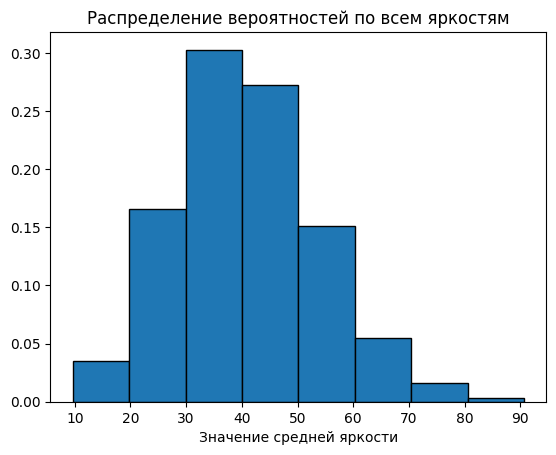

In [ ]:
bins=8
counts, bin_edges = np.histogram(df_part[brightness_list], bins=bins)
print(np.sum(counts))
print(counts)
print(bin_edges)

plt.bar(
    (bin_edges[:-1] + bin_edges[1:]) / 2,   # центры бинов
    counts/np.sum(counts),                                 # высоты столбиков
    width=np.diff(bin_edges),               # ширина столбиков равна ширине бинов
    align='center',
    edgecolor='black'
)

plt.xlabel("Значение средней яркости")
plt.title("Распределение вероятностей по всем яркостям")
plt.show()

1638
[  7 125 453 559 314 137  36   7]
[ 9.68853635 19.8062221  29.92390784 40.04159359 50.15927934 60.27696508
 70.39465083 80.51233658 90.63002232]


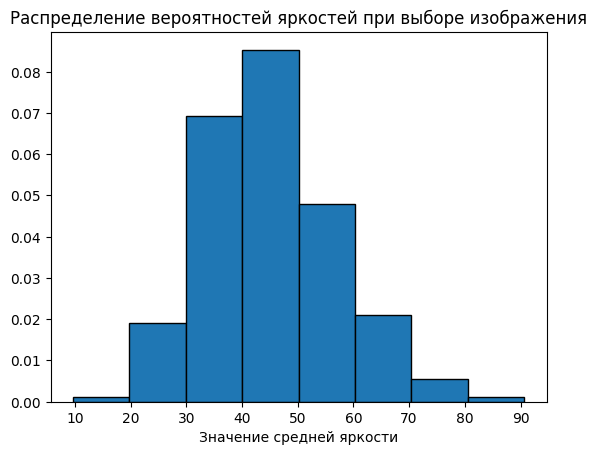

In [ ]:
for index, row in df_part.iterrows():
  for f in brightness_list:
    if str(df_part.loc[index, 'chosen_local_cls']) in f:
      df_part.loc[index, 'chosen_brightness'] = df_part.loc[index, f]

print(df_part['chosen_brightness'].size)
counts1, bin_edges1 = np.histogram(df_part['chosen_brightness'], bins=bins, range=(bin_edges[0], bin_edges[-1])) #density=True
print(counts1)
print(bin_edges1)

plt.bar(
    (bin_edges1[:-1] + bin_edges1[1:]) / 2,   # центры бинов
    counts1/np.sum(counts),                                 # высоты столбиков
    width=np.diff(bin_edges1),               # ширина столбиков равна ширине бинов
    align='center',
    edgecolor='black'
)

plt.xlabel("Значение средней яркости")
plt.title("Распределение вероятностей яркостей при выборе изображения")
plt.show()

4914
[ 222  959 1530 1223  678  222   68   12]
[ 9.68853635 19.8062221  29.92390784 40.04159359 50.15927934 60.27696508
 70.39465083 80.51233658 90.63002232]


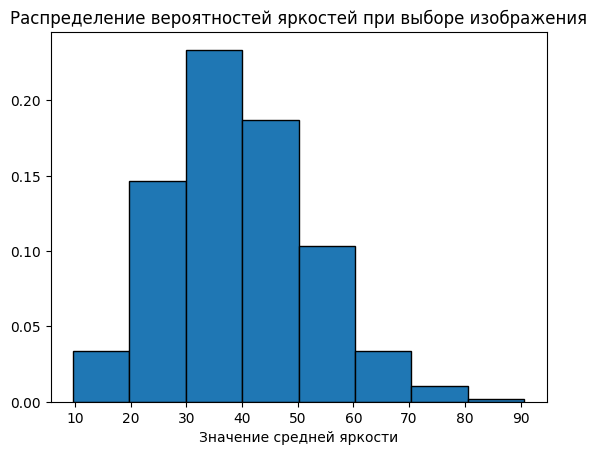

In [ ]:
unchosen_brightness = []

for index, row in df_part.iterrows():
  for f in brightness_list:
    if str(df_part.loc[index, 'chosen_local_cls']) not in f:
      unchosen_brightness.append(df_part.loc[index, f])
print(len(unchosen_brightness))
counts0, bin_edges0 = np.histogram(unchosen_brightness, bins=bins, range=(bin_edges[0], bin_edges[-1])) #density=True
print(counts0)
print(bin_edges0)

plt.bar(
    (bin_edges0[:-1] + bin_edges0[1:]) / 2,   # центры бинов
    counts0/np.sum(counts),                                 # высоты столбиков
    width=np.diff(bin_edges0),               # ширина столбиков равна ширине бинов
    align='center',
    edgecolor='black'
)

plt.xlabel("Значение средней яркости")
plt.title("Распределение вероятностей яркостей при выборе изображения")
plt.show()

[0.01040119 0.04163891 0.08982748 0.13221381 0.13373083 0.17061021
 0.15       0.1627907 ]


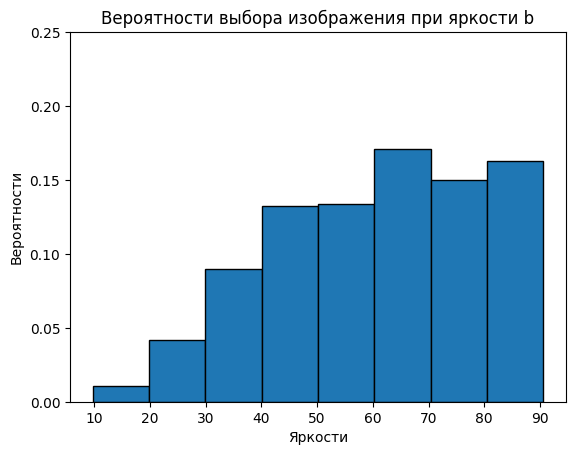

0.8912131365539318


In [ ]:
p_s0 = 0.75
p_s1 = 0.25

counts1g = counts1/np.sum(counts)
counts0g = counts0/np.sum(counts)

p_s1_b_var2 = counts1g * p_s1 / (counts1g*p_s1+counts0g*p_s0)

print(p_s1_b_var2)
plt.bar(
    (bin_edges[:-1] + bin_edges[1:]) / 2,   # центры бинов
    p_s1_b_var2,                                 # высоты столбиков
    width=np.diff(bin_edges),               # ширина столбиков равна ширине бинов
    align='center',
    edgecolor='black'
)
plt.ylim(0, 0.25)
plt.xlabel("Яркости")
plt.ylabel("Вероятности")
plt.title("Вероятности выбора изображения при яркости b")
plt.show()

print(np.sum(p_s1_b_var2))